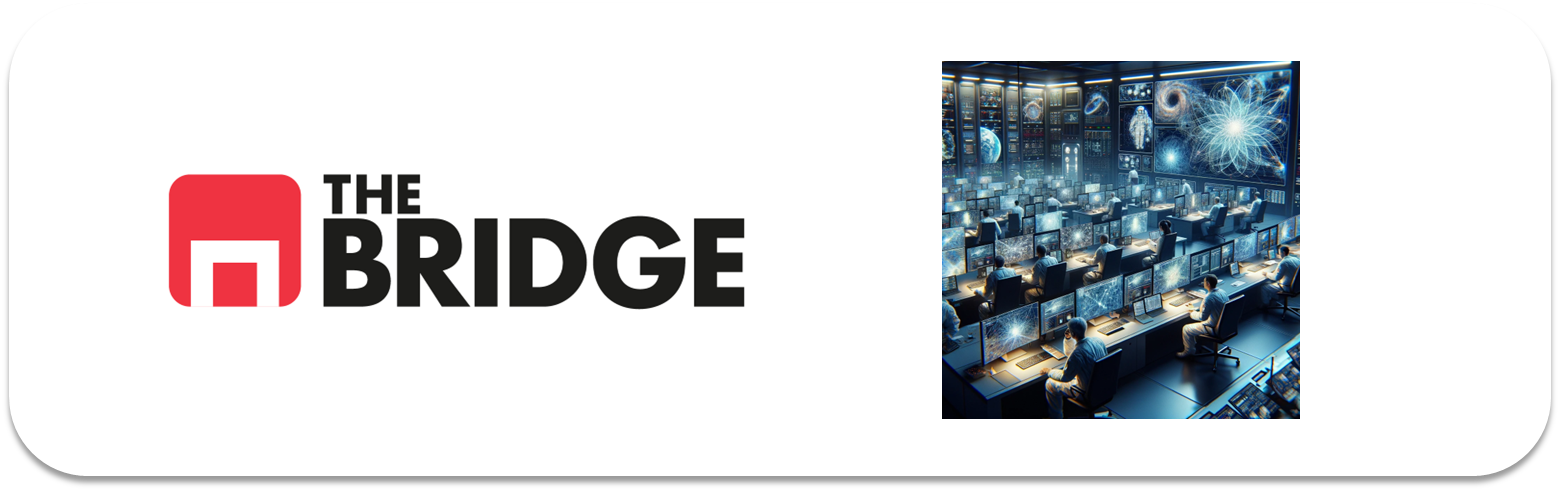

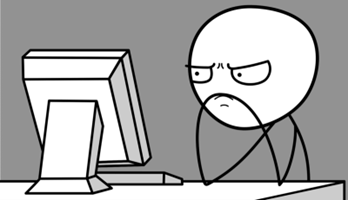

Para ejercitarte y afianzar lo aprendido sobre **Transfer Learning y Fine-tuning**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [52]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import tensorflow as tf



from skimage.io import imread
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import image
from tensorflow.keras import datasets, layers, models


## Apple 360

En este conjunto de ejercicios vas a montar un clasificador de manzanas mediante un dataset de imágenes. El dataset se compone de 13 tipos diferentes con aproximadamente unas 200 imágenes por cada tipo. Tendrás que montar un modelo de deep learning que utilice **transfer learning**. Se sugiere empezar con una red ResNet50 con imagenet.

El dataset original proviene del [concurso de Kaggle Fruits 360](https://www.kaggle.com/moltean/fruits), pero adaptado para la clasificación de una menor cantidad de casos (sólo las manzanas).


### Ejercicio 1

Crea los juegos de X,y para train y test a partir de los datos teninendo en cuenta su distribución, para ello tendrás que explorar las estructura. Crea un juego Train,test para resolución 32x32 y un juego de test adicional para 224x224. Es decir tendras que tener un X_train, X_test para 32x32 y un X_test adicional a 224x224

In [53]:
def read_data(directorio, reshape_dim = (32,32)):
    X = []
    y = []
    for folder in os.listdir(directorio):
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):

                image = cv2.imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim) # Redimensionamos las imágenes a 32x32

                X.append(image)
                y.append(folder)

    return np.array(X),np.array(y)

def read_data2(directorio, reshape_dim = (224,224)):
    X = []
    y = []
    for folder in os.listdir(directorio):
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):

                image = cv2.imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim) # Redimensionamos las imágenes a 32x32

                X.append(image)
                y.append(folder)

    return np.array(X),np.array(y)


In [54]:
x_train, y_train= read_data("./data/apples/train/")

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
x_train,x_val,y_train,y_val  = train_test_split(x_train,y_train)

In [57]:
x_test,y_test = read_data2("./data/apples/test/")

**NOTA:** A partir de aquí emplea siempre el X_train, X_test de 32x32 salvo en el ejercicio que se te diga lo contrario.

### Ejercicio 2

Haz una visualización de algunos de los datos. Crea una función que te ayude con ello.

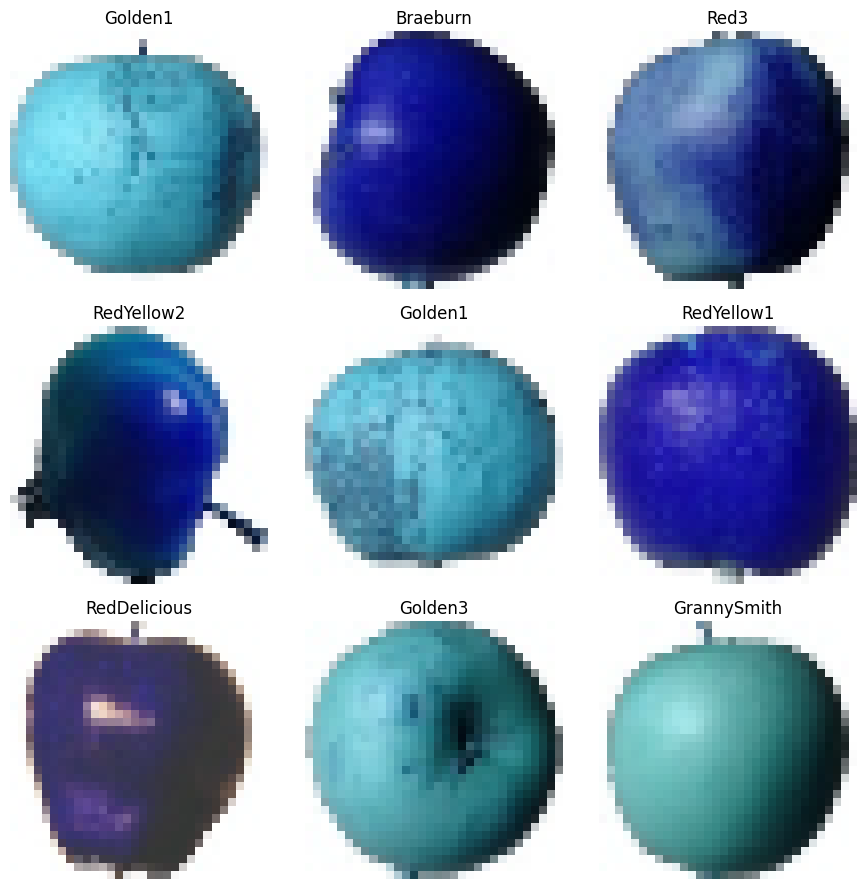

In [58]:
def view_images(X, y=None, num=9):
    """
    Muestra algunas imágenes aleatorias del array X.
    
    Parámetros:
    -----------
    X : np.array
        Array de imágenes, forma (N, H, W, C)
    y : array-like, opcional
        Etiquetas de las imágenes
    num : int
        Número de imágenes a mostrar (cuadrado más cercano)
    """
    # Elegimos imágenes aleatorias
    idx = np.random.choice(len(X), num, replace=False)
    n_cols = int(np.ceil(np.sqrt(num)))
    
    plt.figure(figsize=(n_cols*3, n_cols*3))
    
    for i, index in enumerate(idx):
        img = X[index]
        plt.subplot(n_cols, n_cols, i+1)
        # Si la imagen está en uint8 (0-255) la mostramos tal cual
        # Si está normalizada, igual funciona
        plt.imshow(img.astype(np.uint8))
        if y is not None:
            plt.title(y[index])
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

view_images(x_train,y_train)

### Ejercicio 3

Completa el miniEDA habitual con imágenes y escoge una métrica para el modelo.

<Axes: >

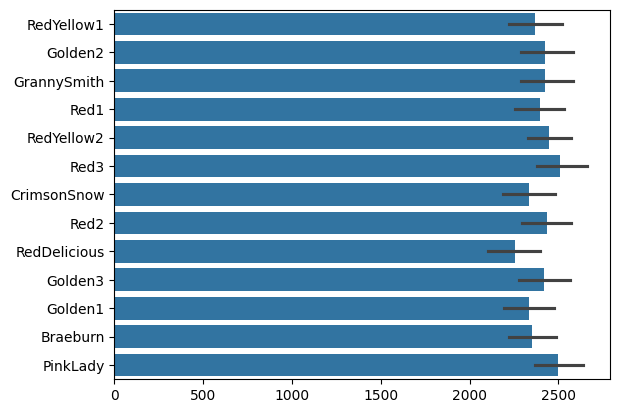

In [59]:
import seaborn as sns
sns.barplot(y_train)

In [60]:
x_train.shape

(4803, 32, 32, 3)

In [61]:
y_train.shape

(4803,)

In [62]:
x_train = x_train/255
x_val = x_val/255
x_test = x_test/255

### Ejercicio 4 

Termina de transformar los datos si crees que es conveniente y aunque el entrenamiento de modelos de keras ya tiene un shuffling interno, haz un "barajado" del X_train (del X_test no es necesario) para facilitar la convergencia inicial del modelo. Utiliza la función shuffle de sklearn y asigna la salida a un X_train distinto (es decir no machaques el inicial)

In [63]:
from sklearn.utils import shuffle

x_train2, y_train = shuffle(x_train, y_train, random_state=42)

### Ejercicio 5

Sklearn permite trabajar con etiquetas textuales pero keras no. Transforma las etiquetas a numéricas, creando dos diccionarios uno que permita traducir de etiqueta a clase numérica y otro que permita la transformación inversa.

In [64]:
mapeo = {"RedYellow1":0,"Golden3":1,"Golden1":2,"PinkLady":3,"RedDelicious":4,"RedYellow2":5,"Golden2":6,"Red3":7,"Red2":8,"Red1":9,"GrannySmith":10,"CrimsonSnow":11,"Braeburn":12}
y_train = pd.DataFrame(y_train)
y_test = pd.DataFrame(y_test)
y_val = pd.DataFrame(y_val)
y_train=y_train[0].map(mapeo)
y_test = y_test[0].map(mapeo)
y_val = y_val[0].map(mapeo)

### Ejercicio 6: Zero Shot Learning

Descar el modelo ResNet50 preparado ya para poder usarlo directamente a la Zero Shot Learning. Pruébalo contra el test (aquí no valen nuestras categorías serán las que proporcione ResNet ojo). Prueba una selección aleatoria de imágenes del test y compara las etiquetas de ResNet con la que tiene. ¿Nos sirve este clasificador así tal cual?

In [ ]:
from tensorflow.keras.applications.resnet_v2 import ResNet50V2, decode_predictions, preprocess_input

In [ ]:

base_model = ResNet50V2(input_shape=(224, 224,3),
                        include_top=True, # Como vamos a emplearla directamente, incluimos también la parte de capas densas que hacen la predicción en este caso clasificación de imagenes 
                        weights="imagenet", # Se carga con los pesos entrenados para el dataset de imagenet
                        classifier_activation="softmax")

In [67]:
base_model.summary()

Model: "resnet50v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_6[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 25,613,800 (97.71 MB)

 Trainable params: 25,568,360 (97.54 MB)

 Non-trainable params: 45,440 (177.50 KB)

In [68]:
preds = base_model.predict(x_test)

67/67 ━━━━━━━━━━━━━━━━━━━━ 54s 757ms/step


In [69]:
y_pred = np.argmax(preds, axis=1)

In [70]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np

def mostrar_imagenes_224(X, y1=None, y2=None, n=9):
    """
    Muestra imágenes con dos etiquetas (por ejemplo: real vs predicción)

    Args:
        X: array (N, 224, 224, 3)
        y1: primera etiqueta (ej: real)
        y2: segunda etiqueta (ej: predicción)
        n: número de imágenes
    """
    indices = np.random.choice(len(X), n, replace=False)
    cols = int(np.sqrt(n))
    
    plt.figure(figsize=(12,12))
    
    for i, idx in enumerate(indices):
        plt.subplot(cols, cols, i+1)
        plt.imshow(X[idx])
        
        titulo = ""
        if y1 is not None:
            titulo += f"Real: {y1[idx]}"
        if y2 is not None:
            titulo += f"\nPred: {y2[idx]}"
        
        plt.title(titulo)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

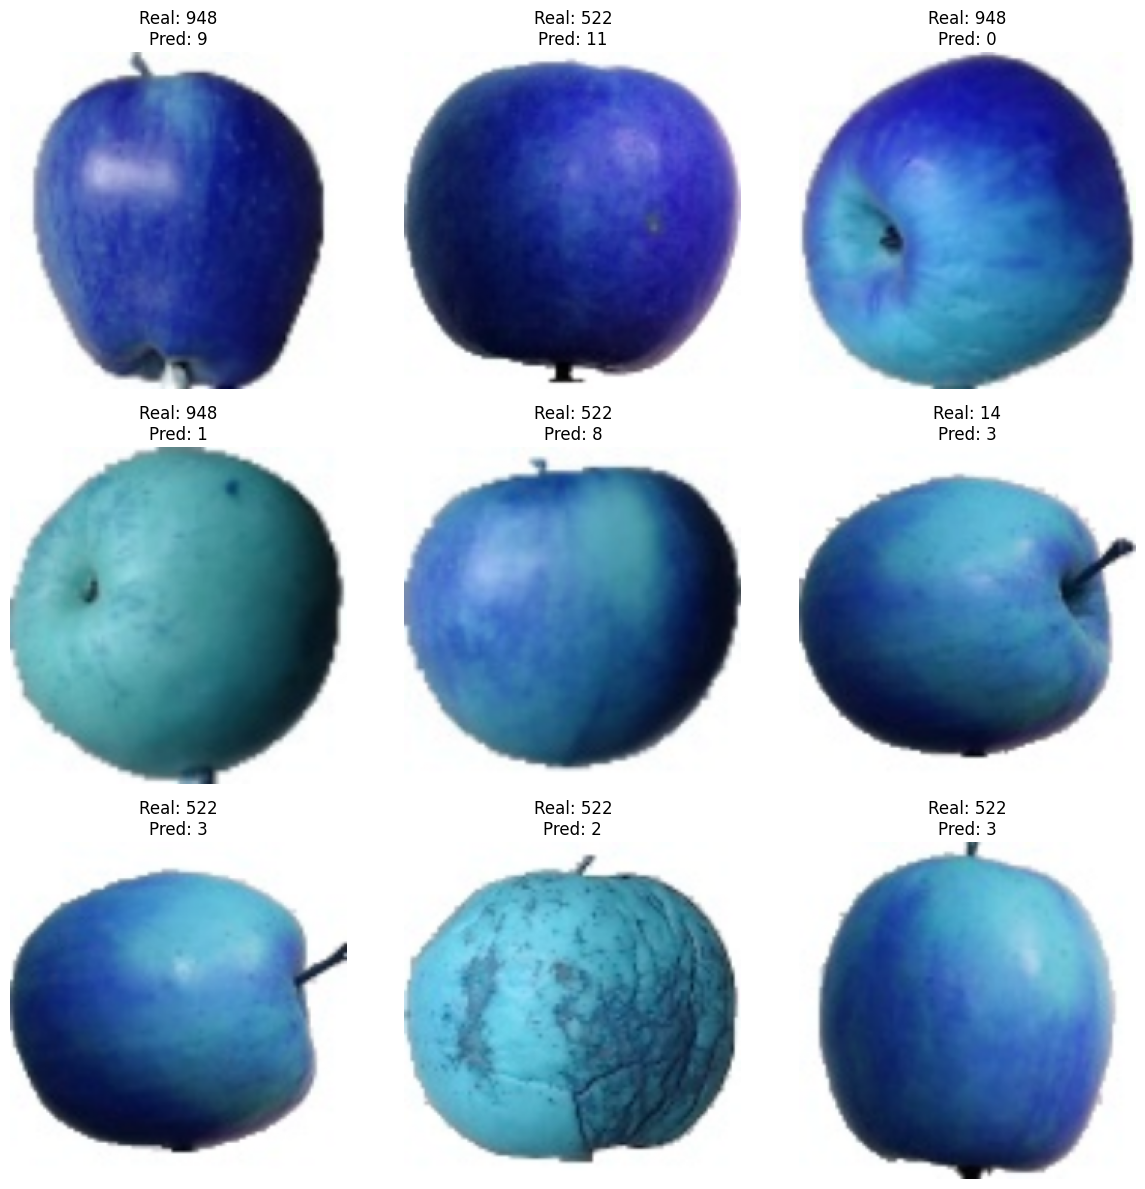

In [71]:
mostrar_imagenes_224(x_test,y_pred,y_test)

## Transfer Learning

### Ejercicio 7:

Carga la ResNet50 sin cabezas, crea un modelo con el anterior y una cabeza con dos capas densas, una oculta de 300 unidades (con activación "relu") y otra de salida con las unidades que crees necesarias y activación la que consideres. Congela las capas del modelo base (la ResNet50). Define también los hiperparámetros necesarios para compilar y compila el modelo y muestra un summary del mismo.

In [96]:
base_model = tf.keras.applications.ResNet50V2(
    input_shape=(32, 32, 3),
    include_top=False,
    weights="imagenet"
)

In [97]:
base_model.trainable = False

In [98]:
# Flatten the output layer to 1 dimension
x = layers.GlobalAveragePooling2D()(base_model.output)

In [99]:
x = layers.Dense(300,activation="relu" )(x)
x = layers.Dense(13,activation="softmax")(x)
model = tf.keras.models.Model(base_model.input, x)

In [100]:
model.compile(optimizer="adam",loss= "sparse_categorical_crossentropy", metrics=["accuracy"])

In [102]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",      # Métrica a vigilar
    patience=5,              # Nº de épocas sin mejora antes de parar
    restore_best_weights=True,  # Recupera los mejores pesos
    verbose=1
)

In [103]:
history = model.fit(x_train2,y_train,batch_size=128,epochs=100,validation_data=(x_val,y_val),callbacks=early_stop)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - accuracy: 1.0000 - loss: 0.0093 - val_accuracy: 0.9981 - val_loss: 0.0124
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 1.0000 - loss: 0.0071 - val_accuracy: 0.9994 - val_loss: 0.0107
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - accuracy: 1.0000 - loss: 0.0056 - val_accuracy: 0.9988 - val_loss: 0.0085
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 1.0000 - loss: 0.0046 - val_accuracy: 0.9988 - val_loss: 0.0072
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.9994 - val_loss: 0.0069
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 0.9988 - val_loss: 0.0059
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.9994 - val_loss: 0.0061
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accu

### Ejercicio 8

Entrena el modelo con nuestros datos de train y muestra la evolución del entrenamiento. Emplea un callback de Earlystopping con patience a 5. Termina de escoger el batch_size y el número de épocas.

### Ejercicio 9

Evalua el modelo contra test y haz un pequeño análisis de las diferencias. Haz un clasification report y muestra la matriz de confusion. Haz un pequeño análisis de errores.

In [107]:
x_test = tf.image.resize(x_test, (32, 32))

In [108]:
predicciones =model.predict(x_test)

67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step


In [111]:
y_pred = np.argmax(predicciones, axis=1)

In [112]:
from sklearn.metrics import classification_report

In [113]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       164
           1       0.78      0.67      0.72       161
           2       0.84      1.00      0.91       160
           3       0.85      0.91      0.88       152
           4       1.00      1.00      1.00       166
           5       0.97      0.96      0.97       219
           6       1.00      0.88      0.94       164
           7       0.86      0.67      0.75       144
           8       0.58      0.81      0.67       164
           9       1.00      0.79      0.88       164
          10       0.98      0.87      0.92       164
          11       0.95      0.91      0.93       148
          12       0.68      0.76      0.72       164

    accuracy                           0.86      2134
   macro avg       0.87      0.86      0.86      2134
weighted avg       0.88      0.86      0.86      2134



## Fine Tuning

### Ejercicio 10

Vuelve a descargar el modelo ResNet50 pero sin pesos entrenados, ni cabeza, crea el mismo modelo personalizado que en el ejercicio 7, compila y muestra el summary.

In [117]:
base_model = tf.keras.applications.ResNet50V2(
    input_shape=(32, 32, 3),
    include_top=False,
    weights=None
)
# Flatten the output layer to 1 dimension
x = layers.GlobalAveragePooling2D()(base_model.output)

x = layers.Dense(300,activation="relu" )(x)
x = layers.Dense(13,activation="softmax")(x)
x=layers.Dropout(0.5)(x)
model = tf.keras.models.Model(base_model.input, x)
model.compile(optimizer="adam",loss= "sparse_categorical_crossentropy", metrics=["accuracy"])
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",      # Métrica a vigilar
    patience=5,              # Nº de épocas sin mejora antes de parar
    restore_best_weights=True,  # Recupera los mejores pesos
    verbose=1
)
history = model.fit(x_train2,y_train,batch_size=128,epochs=100,validation_data=(x_val,y_val),callbacks=early_stop)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 40s 573ms/step - accuracy: 0.3560 - loss: 5.0659 - val_accuracy: 0.0706 - val_loss: 15.2938
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 542ms/step - accuracy: 0.4680 - loss: 2.2748 - val_accuracy: 0.0706 - val_loss: 29.0358
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 552ms/step - accuracy: 0.4254 - loss: 2.9806 - val_accuracy: 0.0706 - val_loss: 92.3423
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 536ms/step - accuracy: 0.4085 - loss: 3.0594 - val_accuracy: 0.1449 - val_loss: 150.6057
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 532ms/step - accuracy: 0.4274 - loss: 2.6395 - val_accuracy: 0.1112 - val_loss: 130.8329
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 540ms/step - accuracy: 0.4354 - loss: 2.6734 - val_accuracy: 0.1999 - val_loss: 104.6536
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


### Ejercicio 11
Entrena con batch_size a 64 y 60 épocas, con un EarlyStopping de patience a 10 (ahora el entrenamiento es sensiblemente más largo, así que tómate un descanso). Muestra la evolución y da una posible justificación a emplear tantas épocas de partida.

### Ejercicio 12

Muestra la evaluación contra el test, el informe de clasificación  y la matriz de confusión. Compara los resultados con los del ejercicio 9.

In [118]:
predicciones =model.predict(x_test)
y_pred = np.argmax(predicciones, axis=1)
print(classification_report(y_test,y_pred))

67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       164
           1       0.00      0.00      0.00       161
           2       0.00      0.00      0.00       160
           3       0.00      0.00      0.00       152
           4       0.00      0.00      0.00       166
           5       0.00      0.00      0.00       219
           6       0.08      1.00      0.14       164
           7       0.00      0.00      0.00       144
           8       0.00      0.00      0.00       164
           9       0.00      0.00      0.00       164
          10       0.00      0.00      0.00       164
          11       0.00      0.00      0.00       148
          12       0.00      0.00      0.00       164

    accuracy                           0.08      2134
   macro avg       0.01      0.08      0.01      2134
weighted avg       0.01      0.08      0.01      2134



c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\javie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave